# Routing Demo on WOMD Map

This notebook demonstrates the complete lane-level routing workflow on a real Waymo Open Motion Dataset (WOMD) map parsed by `Tactics2D`.

The example covers:

1. Loading a WOMD scenario map.
2. Inspecting candidate lanes and selecting a start/goal pair.
3. Running `Router` on the lane graph.
4. Visualizing the planned route directly on the parsed WOMD map.

In [1]:
%matplotlib inline

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from tactics2d.dataset_parser import WOMDParser
from tactics2d.routing import Router

## 1. Load a WOMD scenario map

This example reuses the local WOMD sample shard already used in the existing `womd.ipynb` walkthrough.

In [2]:
parser = WOMDParser()

folder = "../../tactics2d/data/trajectory_sample/WOMD"
file_name = "uncompressed_scenario_validation_interactive_validation_interactive.tfrecord-00000-of-00150"
scenario_id = "234dfbe99b740c80"

map_ = parser.parse_map(scenario_id=scenario_id, file=file_name, folder=folder)
print(f"scenario_id={scenario_id}")
print(f"num_lanes={len(map_.lanes)}")
print(f"boundary={map_.boundary}")

scenario_id=234dfbe99b740c80
num_lanes=664
boundary=(np.float64(11597.0), np.float64(11877.0), np.float64(8180.0), np.float64(8760.0))


## 2. Select start and goal lanes

For a stable and reproducible demo, we use a start lane and a goal lane that have already been verified to produce a valid route on this scenario.

In [3]:
start_lane_id = "00194"
goal_lane_id = "00880"

start_lane = map_.lanes[start_lane_id]
goal_lane = map_.lanes[goal_lane_id]

start = tuple(np.asarray(start_lane.custom_tags["centerline"])[0])
goal = tuple(np.asarray(goal_lane.custom_tags["centerline"])[-1])

print("start_lane_id:", start_lane_id)
print("goal_lane_id:", goal_lane_id)
print("start:", start)
print("goal:", goal)

start_lane_id: 00194
goal_lane_id: 00880
start: (np.float64(11876.475406126598), np.float64(8644.378786460267))
goal: (np.float64(11776.531099531345), np.float64(8264.513297599733))


## 3. Run lane-level routing

The `Router` consumes start and goal **coordinates**. In this demo, we first pick two lanes only to derive stable coordinate samples for a reproducible WOMD example; the actual routing input is still `(start, goal)` in world coordinates.


In [4]:
router = Router(
    algorithm="dijkstra",
    include_neighbors=True,
    lane_change_penalty=10.0,
)

route = router.plan(map_, start, goal)

print("matched start lane:", route.start_lane_id)
print("matched goal lane:", route.goal_lane_id)
print("route length:", len(route.lane_ids))
print("route lane ids:")
print(route.lane_ids)
print("total_cost:", route.total_cost)

matched start lane: 00194
matched goal lane: 00880
route length: 24
route lane ids:
['00194', '00552', '00559', '00558', '00530', '00521', '00501', '00272', '00267', '00284', '00675', '00734', '00737', '00748', '00854', '00744', '00743', '00742', '00938', '00933', '00929', '00875', '00881', '00880']
total_cost: 696.461958825566


## 4. Visualize the route on the WOMD map

We draw both a global overview and a zoomed route-detail view. The notebook also saves the rendered route figure as a PNG under `tests/runtime/routing/`.

In the detail view, labels such as `3` mean the route order of each lane in the planned sequence.

The highlighted route polyline is `route.path`, which is the concatenated geometric path built from routed lane centerlines.


saved figure to: ../../tests/runtime/routing/routing_womd_234dfbe99b740c80.png


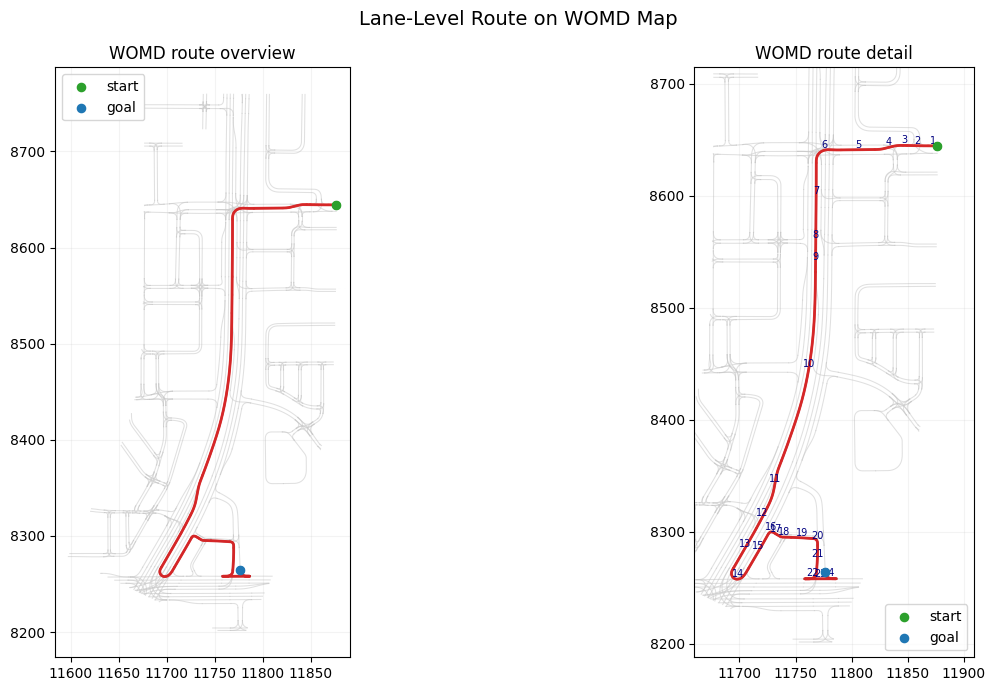

In [5]:
def _plot_map(ax, highlight_lanes=False):
    for lane in map_.lanes.values():
        centerline = lane.custom_tags.get("centerline") if lane.custom_tags is not None else None
        if centerline is None or len(centerline) < 2:
            continue
        centerline = np.asarray(centerline)
        ax.plot(centerline[:, 0], centerline[:, 1], color="0.78", linewidth=0.75, alpha=0.55, zorder=1)

    for lane_idx, lane_id in enumerate(route.lane_ids):
        centerline = np.asarray(map_.lanes[lane_id].custom_tags["centerline"])
        color = plt.cm.Reds(0.65 + 0.25 * lane_idx / max(1, len(route.lane_ids) - 1))
        ax.plot(centerline[:, 0], centerline[:, 1], color=color, linewidth=1.5, zorder=3)
    if route.path is not None:
        path = np.asarray(route.path)
        ax.plot(path[:, 0], path[:, 1], color="#d62728", linewidth=2.0, alpha=0.95, zorder=4)
        ax.scatter(path[0, 0], path[0, 1], color="tab:green", s=30, zorder=5)
        ax.scatter(path[-1, 0], path[-1, 1], color="tab:blue", s=30, zorder=5)

        if highlight_lanes:
            for lane_idx, lane_id in enumerate(route.lane_ids):
                centerline = np.asarray(map_.lanes[lane_id].custom_tags["centerline"])
                lane_mid = centerline[len(centerline) // 2]
                path_idx = np.argmin(np.sum((path - lane_mid) ** 2, axis=1))
                label_x, label_y = path[path_idx]
                ax.text(
                    label_x,
                    label_y,
                    f"{lane_idx + 1}",
                    fontsize=7,
                    color="navy",
                    ha="center",
                    va="bottom",
                    zorder=5,
                )

    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)


fig, axes = plt.subplots(1, 2, figsize=(15, 7))

_plot_map(axes[0], highlight_lanes=False)
axes[0].scatter([route.start[0]], [route.start[1]], color="tab:green", s=35, label="start", zorder=6)
axes[0].scatter([route.goal[0]], [route.goal[1]], color="tab:blue", s=35, label="goal", zorder=6)
axes[0].set_title("WOMD route overview")
axes[0].legend(loc="best")

_plot_map(axes[1], highlight_lanes=True)
axes[1].set_title("WOMD route detail")

if route.path is not None:
    path = np.asarray(route.path)
    x_min, y_min = path.min(axis=0)
    x_max, y_max = path.max(axis=0)
    margin_x = max(20.0, (x_max - x_min) * 0.18)
    margin_y = max(20.0, (y_max - y_min) * 0.18)
    axes[1].set_xlim(x_min - margin_x, x_max + margin_x)
    axes[1].set_ylim(y_min - margin_y, y_max + margin_y)

axes[1].scatter([route.start[0]], [route.start[1]], color="tab:green", s=35, label="start", zorder=6)
axes[1].scatter([route.goal[0]], [route.goal[1]], color="tab:blue", s=35, label="goal", zorder=6)
axes[1].legend(loc="best")

fig.suptitle("Lane-Level Route on WOMD Map", fontsize=14)
fig.tight_layout()

out_dir = Path("../../tests/runtime/routing")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"routing_womd_{scenario_id}.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
print(f"saved figure to: {out_path}")

plt.show()

This example demonstrates a full routing workflow on a real parsed WOMD map:

- coordinates are used as the routing input to `Router`,
- `GraphBuilder` converts lanes into a routing graph,
- `Router` plans a lane sequence between start and goal,
- and the final `Route` is visualized as a highlighted polyline on the scenario map.

This notebook is intended to serve as the reference demo for the lane-level routing module.
